In [1]:
!wget -r -N -c -np https://physionet.org/files/challenge-2019/1.0.0/training/training_setA/

Streaming output truncated to the last 5000 lines.
Saving to: ‘physionet.org/files/challenge-2019/1.0.0/training/training_setA/p007070.psv’

physionet.org/files 100%[===================>]  12.59K  --.-KB/s    in 0s      

2026-06-12 17:00:59 (189 MB/s) - ‘physionet.org/files/challenge-2019/1.0.0/training/training_setA/p007070.psv’ saved [12896/12896]

--2026-06-12 17:00:59--  https://physionet.org/files/challenge-2019/1.0.0/training/training_setA/p007071.psv
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 9100 (8.9K) [text/plain]
Saving to: ‘physionet.org/files/challenge-2019/1.0.0/training/training_setA/p007071.psv’

physionet.org/files 100%[===================>]   8.89K  --.-KB/s    in 0s      

2026-06-12 17:01:00 (143 MB/s) - ‘physionet.org/files/challenge-2019/1.0.0/training/training_setA/p007071.psv’ saved [9100/9100]

--2026-06-12 17:01:00--  https://physionet.org/files/challenge-2019/1.0.0/training/training_setA/p007072.p

In [2]:
!find /content/physionet.org/files/challenge-2019/1.0.0/training/training_setA -name "*.psv" | wc -l

7569


In [27]:
import os
import pandas as pd

folder = "/content/physionet.org/files/challenge-2019/1.0.0/training/training_setA"

files = sorted([f for f in os.listdir(folder) if f.endswith(".psv")])
print("Total files:", len(files))

all_patients = []

for i, file in enumerate(files):
    df = pd.read_csv(os.path.join(folder, file), sep="|")
    df["PatientID"] = i
    all_patients.append(df)

data = pd.concat(all_patients, ignore_index=True)
print(data.shape)
data.head()

Total files: 7569
(293739, 42)


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,PatientID
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,0
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,0


In [33]:
#Step 2 — Patient-level train/val/test split:

from sklearn.model_selection import train_test_split

patient_ids = data["PatientID"].unique()
patient_labels = data.groupby("PatientID")["SepsisLabel"].max()

train_p, temp_p = train_test_split(
    patient_ids, test_size=0.30,
    stratify=patient_labels.loc[patient_ids], random_state=42
)
val_p, test_p = train_test_split(
    temp_p, test_size=0.50,
    stratify=patient_labels.loc[temp_p], random_state=42
)

print("Train patients:", len(train_p))
print("Val patients:", len(val_p))
print("Test patients:", len(test_p))

train_df = data[data["PatientID"].isin(train_p)].copy()
val_df   = data[data["PatientID"].isin(val_p)].copy()
test_df  = data[data["PatientID"].isin(test_p)].copy()

print(train_df.shape, val_df.shape, test_df.shape)

assert set(train_p) & set(val_p) == set()
assert set(train_p) & set(test_p) == set()
assert set(val_p) & set(test_p) == set()

Train patients: 5298
Val patients: 1135
Test patients: 1136
(204828, 42) (44095, 42) (44816, 42)


In [35]:
#Step 3 — Drop columns >95% missing (computed on train only):

missing_pct = train_df.isna().mean() * 100
drop_cols = missing_pct[missing_pct > 95].index.tolist()
drop_cols = [c for c in drop_cols if c not in ["SepsisLabel", "PatientID"]]
print("Dropping:", drop_cols)

train_df = train_df.drop(columns=drop_cols)
val_df   = val_df.drop(columns=drop_cols)
test_df  = test_df.drop(columns=drop_cols)

print(train_df.shape, val_df.shape, test_df.shape)

Dropping: ['EtCO2', 'AST', 'Alkalinephos', 'Calcium', 'Bilirubin_direct', 'Lactate', 'Phosphate', 'Bilirubin_total', 'TroponinI', 'PTT', 'Fibrinogen']
(204828, 31) (44095, 31) (44816, 31)


In [36]:
#step 4: Missingness indicators + per-patient forward-fill + train-fit median imputation

feature_cols = train_df.columns.drop(["SepsisLabel", "PatientID"]).tolist()

# Vitals/labs we'll track missingness for (skip demographics which are rarely missing)
demographics = ["Age", "Gender", "Unit1", "Unit2", "HospAdmTime", "ICULOS"]
clinical_cols = [c for c in feature_cols if c not in demographics]

def add_missingness_indicators(df, cols):
    for c in cols:
        df[c + "_missing"] = df[c].isna().astype(int)
    return df

train_df = add_missingness_indicators(train_df, clinical_cols)
val_df   = add_missingness_indicators(val_df, clinical_cols)
test_df  = add_missingness_indicators(test_df, clinical_cols)

# Per-patient forward fill (carries last known value forward in time)
def patient_ffill(df, cols):
    df = df.sort_values(["PatientID", "ICULOS"])
    df[cols] = df.groupby("PatientID")[cols].ffill()
    return df

train_df = patient_ffill(train_df, clinical_cols)
val_df   = patient_ffill(val_df, clinical_cols)
test_df  = patient_ffill(test_df, clinical_cols)

# Remaining NaNs (never observed for that patient) -> fill with TRAIN median
train_medians = train_df[feature_cols].median()

train_df[feature_cols] = train_df[feature_cols].fillna(train_medians)
val_df[feature_cols]   = val_df[feature_cols].fillna(train_medians)
test_df[feature_cols]  = test_df[feature_cols].fillna(train_medians)

print(train_df.isna().sum().sum(), val_df.isna().sum().sum(), test_df.isna().sum().sum())
print(train_df.shape, val_df.shape, test_df.shape)

0 0 0
(204828, 54) (44095, 54) (44816, 54)


In [37]:
#Step 5 — Time-since-last-observation features + rolling stats
key_vitals = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp"]

def add_time_since_last(df, cols):
    df = df.sort_values(["PatientID", "ICULOS"])
    for c in cols:
        was_missing = df[c + "_missing"]
        # group-wise: count hours since last non-missing observation
        df["tsl_" + c] = (
            was_missing.groupby(df["PatientID"])
            .apply(lambda s: s.groupby((s == 0).cumsum()).cumcount())
            .reset_index(drop=True)
        )
    return df

def add_rolling_stats(df, cols, window=6):
    df = df.sort_values(["PatientID", "ICULOS"])
    for c in cols:
        grp = df.groupby("PatientID")[c]
        df[c + "_rollmean"] = grp.transform(
            lambda s: s.rolling(window, min_periods=1).mean()
        )
        df[c + "_rollstd"] = grp.transform(
            lambda s: s.rolling(window, min_periods=1).std().fillna(0)
        )
    return df

train_df = add_time_since_last(train_df, key_vitals)
val_df   = add_time_since_last(val_df, key_vitals)
test_df  = add_time_since_last(test_df, key_vitals)

train_df = add_rolling_stats(train_df, key_vitals)
val_df   = add_rolling_stats(val_df, key_vitals)
test_df  = add_rolling_stats(test_df, key_vitals)

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

(204828, 75) (44095, 75) (44816, 75)


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,BaseExcess,HCO3,FiO2,...,Temp_rollmean,Temp_rollstd,SBP_rollmean,SBP_rollstd,MAP_rollmean,MAP_rollstd,DBP_rollmean,DBP_rollstd,Resp_rollmean,Resp_rollstd
0,84.0,98.0,36.94,118.0,77.00,59.0,18.0,0.0,24.0,0.50,...,36.94,0.0,118.000000,0.000000,77.000000,0.000000,59.0,0.0,18.000000,0.000000
1,97.0,95.0,36.94,98.0,75.33,59.0,19.0,0.0,24.0,0.50,...,36.94,0.0,108.000000,14.142136,76.165000,1.180868,59.0,0.0,18.500000,0.707107
2,89.0,99.0,36.94,122.0,86.00,59.0,22.0,0.0,24.0,0.50,...,36.94,0.0,112.666667,12.858201,79.443333,5.739306,59.0,0.0,19.666667,2.081666
3,90.0,95.0,36.94,122.0,86.00,59.0,30.0,24.0,24.0,0.50,...,36.94,0.0,115.000000,11.489125,81.082500,5.719023,59.0,0.0,22.250000,5.439056
4,103.0,88.5,36.94,122.0,91.33,59.0,24.5,24.0,24.0,0.28,...,36.94,0.0,116.400000,10.430724,83.132000,6.747790,59.0,0.0,22.700000,4.816638


In [38]:
#Step 6 — Label noise discussion + simple mitigation (transition smoothing)
def add_transition_flag(df):
    df = df.sort_values(["PatientID", "ICULOS"])
    df["label_shift"] = df.groupby("PatientID")["SepsisLabel"].diff().fillna(0)
    df["near_transition"] = df["label_shift"].abs()
    # mark the transition row itself; we'll use this for sample weighting
    return df

train_df = add_transition_flag(train_df)
val_df   = add_transition_flag(val_df)
test_df  = add_transition_flag(test_df)

# Sample weights: down-weight transition rows slightly (label timing most uncertain there)
train_df["sample_weight"] = np.where(train_df["near_transition"] == 1, 0.5, 1.0)

print(train_df["near_transition"].sum(), train_df.shape)

409.0 (204828, 78)


In [39]:
#Step 7 — Prepare matrices and train baseline model
from sklearn.ensemble import RandomForestClassifier

drop_for_X = ["SepsisLabel", "PatientID", "label_shift", "near_transition", "sample_weight"]

X_train = train_df.drop(columns=drop_for_X)
y_train = train_df["SepsisLabel"]
w_train = train_df["sample_weight"]

X_val = val_df.drop(columns=[c for c in drop_for_X if c in val_df.columns])
y_val = val_df["SepsisLabel"]

X_test = test_df.drop(columns=[c for c in drop_for_X if c in test_df.columns])
y_test = test_df["SepsisLabel"]

print(X_train.shape, X_val.shape, X_test.shape)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train, sample_weight=w_train)

(204828, 73) (44095, 73) (44816, 73)


RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [40]:
#Step 8 — Calibration (fit on train, calibrate using a separate fold of train — NOT val/test)
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    estimator=RandomForestClassifier(
        n_estimators=200, max_depth=12,
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    method="sigmoid",
    cv=3
)

calibrated_model.fit(X_train, y_train, sample_weight=w_train)

val_probs = calibrated_model.predict_proba(X_val)[:, 1]
test_probs = calibrated_model.predict_proba(X_test)[:, 1]

print(val_probs[:10])

[0.01730941 0.01305811 0.01309406 0.01362367 0.01215181 0.01179005
 0.01213974 0.01299608 0.01188374 0.00748866]


In [41]:
#Step 9 — Threshold tuning on VALIDATION set only
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_val, val_probs)
f1 = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("Best threshold (on val):", best_threshold)
print("Val F1 at this threshold:", f1[best_idx])
print("Val precision/recall:", precision[best_idx], recall[best_idx])

Best threshold (on val): 0.060053067656651714
Val F1 at this threshold: 0.13927227097493516
Val precision/recall: 0.09840425531914894 0.23819742489270387


In [42]:
#9b
from sklearn.metrics import roc_auc_score, average_precision_score

print("Sepsis rate (train):", y_train.mean())
print("Sepsis rate (val):", y_val.mean())

print("Val ROC-AUC:", roc_auc_score(y_val, val_probs))
print("Val AUPRC:", average_precision_score(y_val, val_probs))

Sepsis rate (train): 0.02114945222332884
Sepsis rate (val): 0.02113618324073024
Val ROC-AUC: 0.7471812484643748
Val AUPRC: 0.06354718089148573


In [43]:
#10
!pip install xgboost -q
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train, sample_weight=w_train)

val_probs_xgb = xgb_model.predict_proba(X_val)[:, 1]
test_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Val ROC-AUC (xgb):", roc_auc_score(y_val, val_probs_xgb))
print("Val AUPRC (xgb):", average_precision_score(y_val, val_probs_xgb))

scale_pos_weight: 46.282548476454295
Val ROC-AUC (xgb): 0.6896881881726112
Val AUPRC (xgb): 0.06493475732248497


In [44]:
#10b
xgb_model2 = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

xgb_model2.fit(X_train, y_train, sample_weight=w_train)

val_probs_xgb2 = xgb_model2.predict_proba(X_val)[:, 1]

print("Val ROC-AUC (xgb tuned):", roc_auc_score(y_val, val_probs_xgb2))
print("Val AUPRC (xgb tuned):", average_precision_score(y_val, val_probs_xgb2))

Val ROC-AUC (xgb tuned): 0.744364982764705
Val AUPRC (xgb tuned): 0.07647966705870496


In [45]:
#10c
model_deep = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
model_deep.fit(X_train, y_train, sample_weight=w_train)

val_probs_rf2 = model_deep.predict_proba(X_val)[:, 1]

print("Val ROC-AUC (rf deep):", roc_auc_score(y_val, val_probs_rf2))
print("Val AUPRC (rf deep):", average_precision_score(y_val, val_probs_rf2))

Val ROC-AUC (rf deep): 0.7595114919699046
Val AUPRC (rf deep): 0.06414605760039638


In [47]:
import numpy as np

w_train_f32 = w_train.astype(np.float32)

calibrated_xgb = CalibratedClassifierCV(
    estimator=xgb.XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
        random_state=42, n_jobs=-1
    ),
    method="sigmoid",
    cv=3
)

calibrated_xgb.fit(X_train, y_train, sample_weight=w_train_f32)

val_probs_cal = calibrated_xgb.predict_proba(X_val)[:, 1]
test_probs_cal = calibrated_xgb.predict_proba(X_test)[:, 1]

print("Val ROC-AUC (calibrated):", roc_auc_score(y_val, val_probs_cal))
print("Val AUPRC (calibrated):", average_precision_score(y_val, val_probs_cal))

Val ROC-AUC (calibrated): 0.753732507545258
Val AUPRC (calibrated): 0.07842933805098332


In [48]:
#Step 12 — Threshold tuning on val:
precision, recall, thresholds = precision_recall_curve(y_val, val_probs_cal)
f1 = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("Best threshold (val):", best_threshold)
print("Val F1/precision/recall:", f1[best_idx], precision[best_idx], recall[best_idx])

Best threshold (val): 0.07000807466973613
Val F1/precision/recall: 0.15248551383549283 0.10651896037494674 0.26824034334763946


Test ROC-AUC: 0.7998695786306002
Test AUPRC: 0.10328998123497299
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     43891
           1       0.13      0.30      0.18       925

    accuracy                           0.94     44816
   macro avg       0.56      0.63      0.57     44816
weighted avg       0.97      0.94      0.95     44816



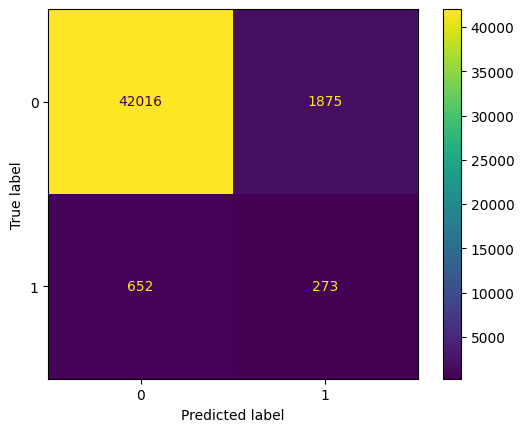

In [49]:
#Step 13 — Final test evaluation:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

test_preds = (test_probs_cal >= best_threshold).astype(int)

print("Test ROC-AUC:", roc_auc_score(y_test, test_probs_cal))
print("Test AUPRC:", average_precision_score(y_test, test_probs_cal))
print(classification_report(y_test, test_preds))

cm = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(cm).plot()
plt.savefig("confusion_matrix.png")
plt.show()

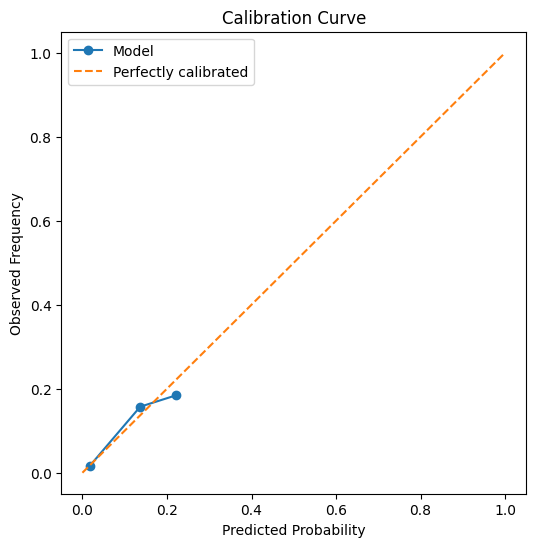

In [50]:
#Step 14 — Calibration curve:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, test_probs_cal, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0,1], [0,1], "--", label="Perfectly calibrated")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.legend()
plt.savefig("calibration_curve.png")
plt.show()